In [ ]:
import numpy as np
from utils.run_experiment import *

In [33]:
quantum_ops_count = 0

def reset_quantum_ops():
    global quantum_ops_count
    quantum_ops_count = 0

In [34]:
def adj_to_matrix(adj_list):
    n = len(adj_list)
    INF = float('inf')
    mat = [[INF]*n for _ in range(n)]
    for i in range(n): 
        mat[i][i] = 0
    for u in range(n):
        for v, w in adj_list[u]:
            if w < mat[u][v]:
                mat[u][v] = w
    return mat


def floyd_warshall_classic(matrix):
    global quantum_ops_count
    reset_quantum_ops()
    n = len(matrix)
    dist = [row[:] for row in matrix]
    
    for k in range(n):
        for i in range(n):
            if dist[i][k] == float('inf'):
                continue
            for j in range(n):
                quantum_ops_count += 1 
                new_dist = dist[i][k] + dist[k][j]
                if new_dist < dist[i][j]:
                    dist[i][j] = new_dist
                    
    return dist, quantum_ops_count

In [35]:
def grover(target_state: str, initial_state: np.ndarray, num_iterations: int = 1):
    n = len(target_state)
    N = 2 ** n
    if len(initial_state) != N:
        if len(initial_state) < N:
            temp = np.zeros(N)
            temp[:len(initial_state)] = initial_state
            initial_state = temp
        else:
            initial_state = initial_state[:N]
            
    norm = np.linalg.norm(initial_state)
    if norm == 0: 
        return initial_state, np.zeros(N)
    if not np.isclose(norm, 1.0):
        initial_state = initial_state / norm

    target_index = int(target_state, 2)
    state = initial_state.copy()

    for _ in range(num_iterations):
        state[target_index] *= -1
        mean = np.mean(state)
        state = 2 * mean - state

    probabilities = np.abs(state) ** 2

    return state, probabilities

In [36]:
def floyd_warshall_quantum(matrix):
    """
    Квантовый FW: Внутренний цикл по j заменен на Grover O(sqrt(V)).
    Эвристика: ищем вершину j, дающую минимальное значение dist[i][k] + dist[k][j].
    """
    global quantum_ops_count
    reset_quantum_ops()
    n = len(matrix)
    dist = [row[:] for row in matrix]
    
    if n == 0: return dist, 0
    
    n_qubits = int(np.ceil(np.log2(max(n, 1))))
    N = 2 ** n_qubits
    initial_state = np.ones(N) / np.sqrt(N)
    num_iters = max(1, int(np.round((np.pi / 4) * np.sqrt(N))))

    for k in range(n):
        for i in range(n):
            if dist[i][k] == float('inf'): continue
            
            min_val = float('inf')
            best_j = -1
            
            for j in range(n):
                val = dist[i][k] + dist[k][j]
                if val < min_val:
                    min_val = val
                    best_j = j
            
            quantum_ops_count += int(np.sqrt(n))
            
            # Теперь проверяем, дало ли это улучшение
            if best_j == -1 or min_val >= dist[i][best_j]:
                continue
                
            target_binary = format(best_j, f'0{n_qubits}b')
            _, probs = grover(target_binary, initial_state, num_iters)
            measured_j = np.argmax(probs)
            
            actual_j = measured_j if measured_j < n else best_j
            new_dist = dist[i][k] + dist[k][actual_j]
            
            if new_dist < dist[i][actual_j]:
                dist[i][actual_j] = new_dist
                
    return dist, quantum_ops_count

In [37]:
def floyd_warshall_classic_wrapper(adj_list, n, edges):
    return floyd_warshall_classic(adj_to_matrix(adj_list))

def floyd_warshall_quantum_wrapper(adj_list, n, edges):
    return floyd_warshall_quantum(adj_to_matrix(adj_list))

fw_algos = {
    "Floyd-Warshall Classic": floyd_warshall_classic_wrapper,
    "Floyd-Warshall Quantum": floyd_warshall_quantum_wrapper
}

res_fw = run_experiment(fw_algos)

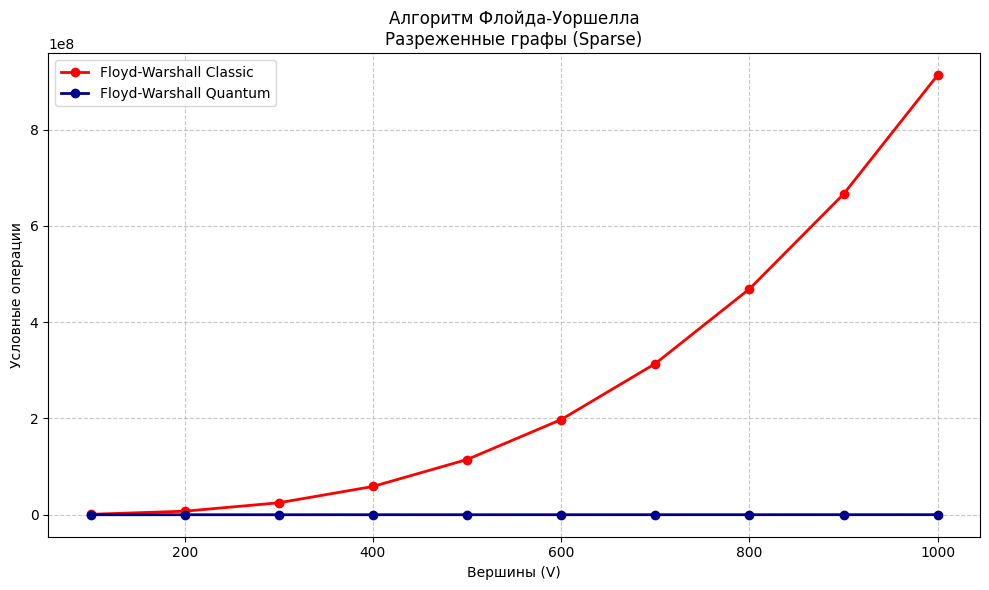

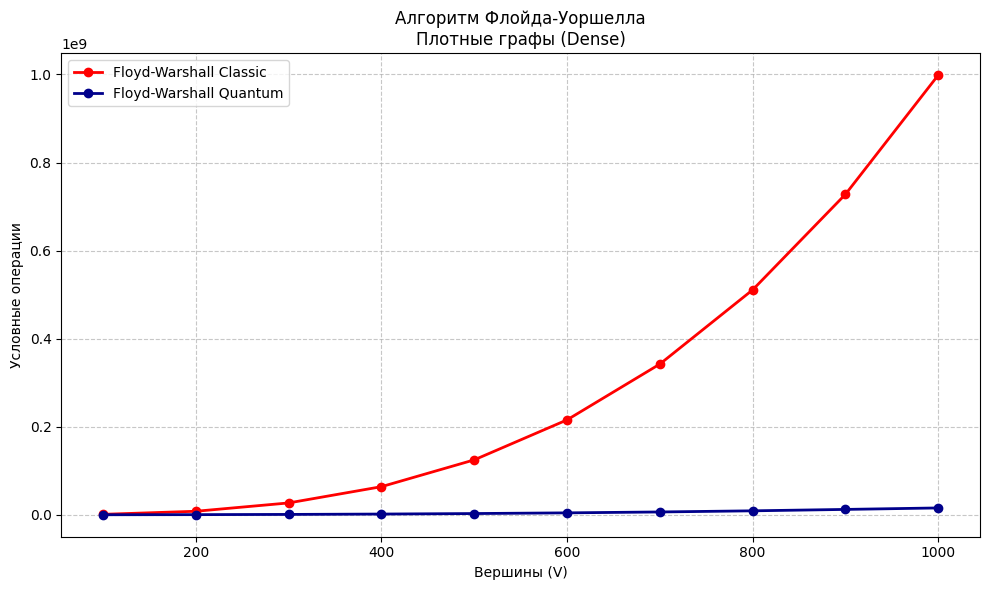

In [38]:
plot_results(res_fw, title_prefix="Алгоритм Флойда-Уоршелла")

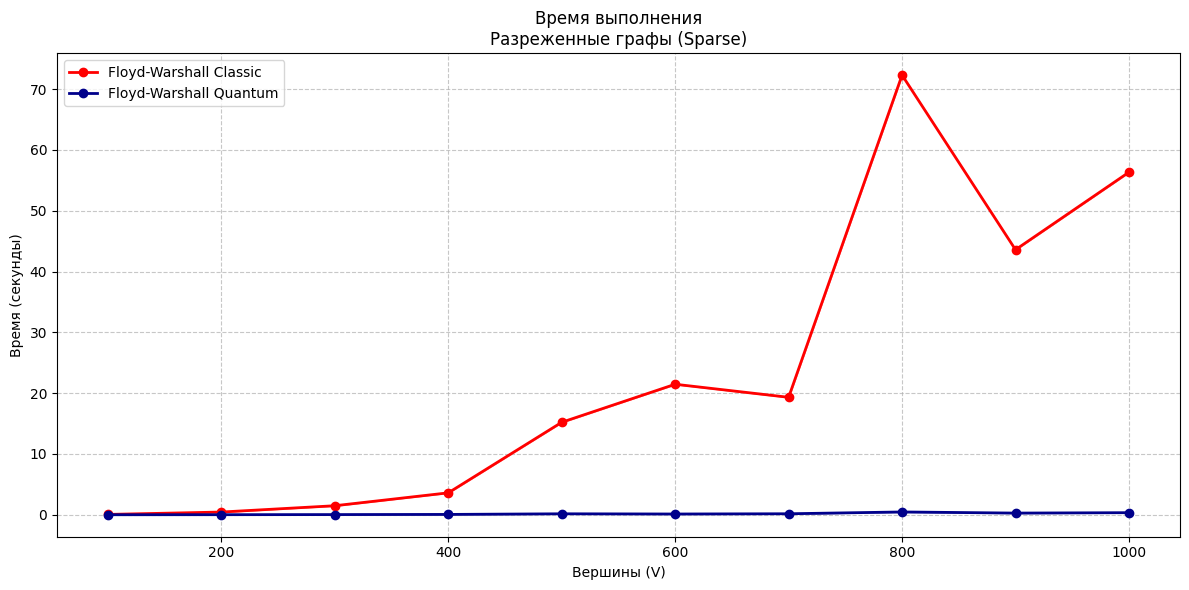

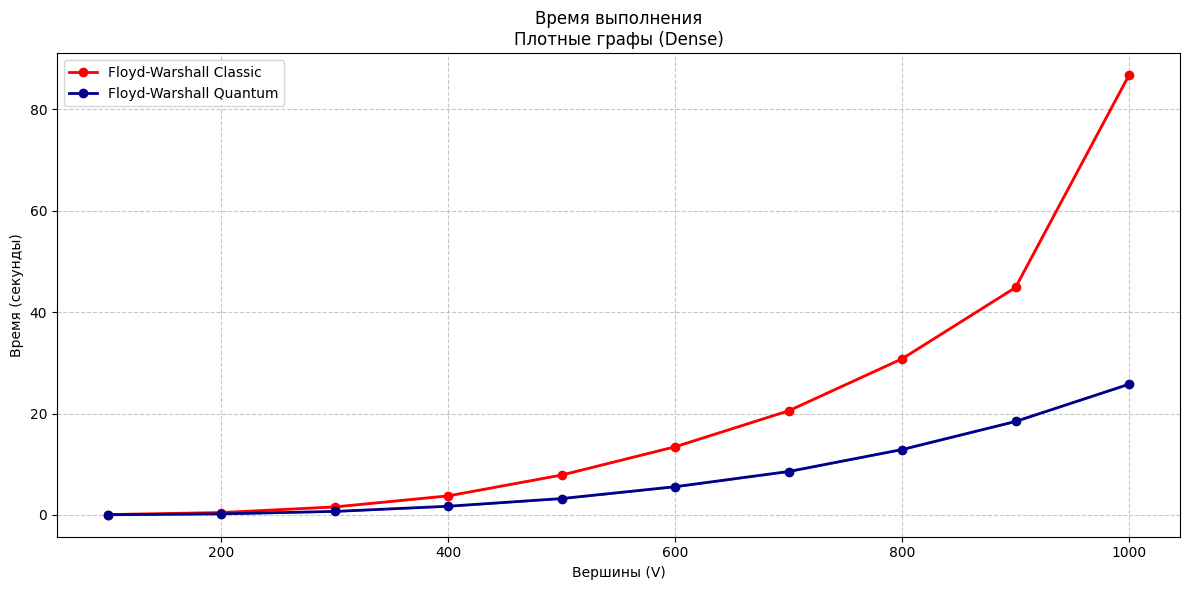

In [39]:
plot_time(res_fw)